In [91]:
import argparse
import json

import sys
sys.path.append("../..")

from tqdm import tqdm

from monai.networks.nets import DiffusionModelUNet
import torch

from monai.utils import set_determinism
import os
import csv

import utils.simplex_ddpm as simplex_ddpm

import AnoDDPM.simplex as simplex
from skimage import exposure
from scipy.ndimage import gaussian_filter, grey_dilation, grey_closing

import numpy as np
import matplotlib.pyplot as plt
import copy

from scipy import stats

from datasets import anomaly_datasets
from utils.utils import *

import lpips

In [92]:
DEVICE_TYPE = "cuda:0"
device = torch.device(DEVICE_TYPE)

set_determinism(0)

#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [93]:

IMAGE_SIZE = 128

torch.backends.cudnn.benchmark = True
torch.set_num_threads(torch.get_num_threads())
torch.autograd.set_detect_anomaly(False)

In [94]:
model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(32, 64, 64, 64),
    attention_levels=(False, True, True, True),
    num_head_channels=8,
    use_flash_attention=True,
)
model.to(device)

model_path = ROOT_DIR+"AnoDiffExperiments/experiment_2/exp_2_2/models/exp_2_2_best_model.pth"
model.load_state_dict(torch.load(model_path, map_location=DEVICE_TYPE))

model.eval()



DiffusionModelUNet(
  (conv_in): Convolution(
    (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (time_embed): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock(
      (resnets): ModuleList(
        (0-1): 2 x DiffusionUNetResnetBlock(
          (norm1): GroupNorm(32, 32, eps=1e-06, affine=True)
          (nonlinearity): SiLU()
          (conv1): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (time_emb_proj): Linear(in_features=128, out_features=32, bias=True)
          (norm2): GroupNorm(32, 32, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (skip_connection): Identity()
        )
      )
      (downsampler): Diffus

In [95]:
infer_scheduler = simplex_ddpm.SimplexDDPMScheduler(num_train_timesteps=1000, schedule="cosine")

### Thor specifics

In [96]:
l_pips_sq = lpips.LPIPS(pretrained=True, pnet_rand=False, net='squeeze', eval_mode=True, spatial=True, lpips=True).to(device)

Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [on]
Loading model from: /bettik/PROJECTS/pr-gin5_aini/fehrdelt/environments/ddpm_env/lib/python3.9/site-packages/lpips/weights/v0.1/squeeze.pth


The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.


In [97]:
def lpips_loss(anomaly_img, ph_img, retPerLayer=False):
    """
    :param anomaly_img: anomaly image
    :param ph_img: pseudo-healthy image
    :param retPerLayer: whether to return the loss per layer
    :return: LPIPS loss
    """
    if len(ph_img.shape) == 2:
        ph_img = torch.unsqueeze(torch.unsqueeze(ph_img, 0), 0)
        anomaly_img = torch.unsqueeze(torch.unsqueeze(anomaly_img, 0), 0)
    

    anomaly_img = ((anomaly_img * 2) - 1).repeat(1,3,1,1)
    ph_img = ((ph_img * 2) - 1).repeat(1,3,1,1)

    loss_lpips = l_pips_sq(anomaly_img, ph_img, normalize=True, retPerLayer=retPerLayer)
    if retPerLayer:
        loss_lpips = loss_lpips[1][0]
    return loss_lpips.cpu().detach().numpy()

In [98]:
def get_saliency( x, x_rec, retPerLayer=False):
    saliency = lpips_loss(x, x_rec, retPerLayer)
    saliency = gaussian_filter(saliency, sigma=2)
    return saliency

In [99]:
def compute_residual(x, x_rec, hist_eq=False):
    """
    :param x_rec: reconstructed image
    :param x: original image
    :param hist_eq: whether to perform histogram equalization
    :return: residual image
    """
    if hist_eq:
        x_rescale = exposure.equalize_adapthist(x.cpu().detach().numpy())
        x_rec_rescale = exposure.equalize_adapthist(x_rec.cpu().detach().numpy())
        x_res = np.abs(x_rec_rescale - x_rescale)
    else:
        x_res = np.abs(x_rec.cpu().detach().numpy() - x.cpu().detach().numpy())

    return x_res

In [100]:
def get_anomaly_mask(x, x_rec, hist_eq=False, retPerLayer=False):

    x_res = compute_residual(x, x_rec, hist_eq=hist_eq)

    lpips_mask = get_saliency(x, x_rec, retPerLayer=retPerLayer).clip(0,1) 

    x_res2 = np.asarray([(x_res[i] / (np.percentile(x_res[i], 95) + 1e-8)) for i in range(x_res.shape[0])]).clip(0, 1)

    combined_mask_np = lpips_mask * x_res #+ x_res) / 2
    combined_mask_np2 = (lpips_mask * x_res) # x_res2
    # # anomalous: high value, healthy: low value

    # combined_mask_np = area_opening((combined_mask_np * 255).astype(np.uint8)) / 255.0#, square(7))
    # combined_mask_np = closing((combined_mask_np * 255).astype(np.uint8), footprint=np.ones(9,9)) / 255.0#, square(7))
    # # combined_mask_np = ndimage.grey_dilation((combined_mask_np * 255).astype(np.uint8), size=(3)) / 255.0#, square(7))
    
    combined_mask = torch.Tensor(combined_mask_np).to(device)
    # combined_mask = dilate_masks(combined_mask)
    
    combined_mask2 = torch.Tensor(combined_mask_np2).to(device)

    combined_mask = (combined_mask / (torch.max(combined_mask) + 1e-8)).clip(0,1)
    # x_res_neg = (x-x_rec)
    return combined_mask, combined_mask2, torch.Tensor(x_res).to(device)
    # return torch.Tensor(x_res).to(device), torch.Tensor(x_res).to(device), torch.Tensor(x_res).to(device)

In [101]:
def get_region_anomaly_mask(ano_map, kernel_size=13):
    # input_image_ = (np.squeeze(copy.deepcopy(input_image).cpu().detach().numpy())*255).astype(np.uint8)
    final_anomaly_map = (grey_closing(ano_map, size=(1,1,kernel_size,kernel_size), mode='nearest'))#+ ano_map)/2
    final_anomaly_map = (grey_dilation(final_anomaly_map, size=(1,1,kernel_size,kernel_size), mode='nearest') + ano_map)/2
    final_anomaly_map = final_anomaly_map.clip(0,1)
    # final_anomaly_map = ((2**final_anomaly_map)-1).clip(0,1)
    return final_anomaly_map

In [102]:
NOISE_MIN = int(0.05*1000)
NOISE_MAX = int(0.35*1000)+1

TypeError: 'Tensor' object is not callable

In [209]:
@torch.no_grad()
def my_sample(image, infer_scheduler, timesteps, octaves=6, frequency=64, return_intermediates=False):
    
    simplexObj = simplex.Simplex_CLASS()

    noise = my_generate_simplex_noise(simplexObj, image.shape, octaves=octaves, frequency=frequency, normalize=False).to(device)
    
    if timesteps >= infer_scheduler.num_train_timesteps:
        print(timesteps, "is too high. Setting to", infer_scheduler.num_train_timesteps-1)

    timesteps_list = torch.Tensor([timesteps for a in range(image.shape[0])]).to(image.device).long()

    image = infer_scheduler.add_noise(image, noise, timesteps_list).to(device) #TODO


    intermediates = []
    intermediates_step = 20

            
    for t in tqdm(range(timesteps, 0, -1)): # va de timesteps à 0
        
        model_output = model(
            image, timesteps=torch.Tensor((t,)).to(device), context=None
        )
        #print(model_output.shape)
        
        image, _ = infer_scheduler.step(model_output, t, image)
    
        if (t== timesteps-1 or t%intermediates_step == 0 or t==1) and return_intermediates:
            intermediates.append(image)

    if return_intermediates:
        return image, intermediates
    else:
        return image

In [ ]:
@torch.no_grad()
def sample_thor(image, infer_scheduler, timesteps, timesteps_harmonization, return_intermediates=False):
    
    if timesteps >= infer_scheduler.num_train_timesteps:
        print(timesteps, "is too high. Setting to", infer_scheduler.num_train_timesteps-1)
    
    timesteps_list = torch.Tensor([timesteps for a in range(image.shape[0])]).to(image.device).long()

    simplexObj = simplex.Simplex_CLASS()

    original_image = copy.deepcopy(image)

    noise = simplex_ddpm.generate_simplex_noise(simplexObj, image.shape).to(device)

    image = infer_scheduler.add_noise(image, noise, timesteps_list).to(device) #TODO
    

    intermediates_mixed_images_visualize = []
    intermediates_pseudo_anomaly_masks = []
    intermediates_pseudo_anomaly_masks_processed = []

            
    for t in tqdm(range(timesteps, 0, -1)): # goes from timesteps to 0
        
        # compute previous image
        model_output = model(image, timesteps=torch.Tensor((t,)).to(device), context=None)
        image, image_before_step = infer_scheduler.step(model_output, t, image) # here image_before_step is just the image at the timestep+1
            
        
        if t in timesteps_harmonization:
            
            
            pseudo_anomaly_mask, _, _ = get_anomaly_mask(copy.deepcopy(image_before_step), copy.deepcopy(original_image), hist_eq=False)
            
            intermediates_pseudo_anomaly_masks.append(pseudo_anomaly_mask)
            pseudo_anomaly_mask = pseudo_anomaly_mask.cpu().detach().numpy()
            

            pseudo_anomaly_mask_processed = torch.Tensor(get_region_anomaly_mask(pseudo_anomaly_mask, kernel_size=4)).to(device).clip(0,1) # simple erosion dilation 
            

            pseudo_anomaly_mask_processed = pseudo_anomaly_mask_processed.clip(0,1) 

            intermediates_pseudo_anomaly_masks_processed.append(pseudo_anomaly_mask_processed)

            image_0 = pseudo_anomaly_mask_processed * image_before_step + (1-pseudo_anomaly_mask_processed) * original_image
            
            image_0 = torch.clamp(image_0, 0, 1)
            
            
            image = infer_scheduler.add_noise(image_0, noise, torch.Tensor((t,)).to(device).long())
            
            intermediates_mixed_images_visualize.append(image)

    if return_intermediates:
        return image, intermediates_mixed_images_visualize, intermediates_pseudo_anomaly_masks, intermediates_pseudo_anomaly_masks_processed
    else:
        return image, intermediates_pseudo_anomaly_masks

**play with get_region_anomaly_mask() parameters** \
**Verif lpips_loss**

In [ ]:
config_dict = json.load(open(ROOT_DIR+"AnoDiffExperiments/experiment_2/exp_2_2/config.json", "r"))

config_dict["root_dir"] = ROOT_DIR

In [ ]:
args = argparse.Namespace(**config_dict)

In [ ]:
print(args)

Namespace(experiment_name='experiment_2', sub_experiment_name='exp_2_2', description='2D DDPM on adc with gaussian noise, validation on whole volume', pipeline=['train_ddpm_full_volume', 'compute_metrics_reconstruction', 'compute_metrics_anomaly_detection'], spatial_dims=2, spatial_dims_val_test=3, image_size=128, root_dir='/bettik/PROJECTS/pr-gin5_aini/fehrdelt/', dataset={'name': 'final_adc_dataset_small_added_ixi', 'test': 'soop', 'save_anomaly_maps': True, 'batch_size': 16, 'num_workers': 16, 'slice_indexes_start': 22, 'slice_indexes_end': 94}, show_summary_figures=True, slice_indexes_start=22, slice_indexes_end=94, train_transforms={'_target_': 'monai.transforms.Compose', 'transforms': [{'_target_': 'monai.transforms.LoadImage', 'image_only': True}, {'_target_': 'monai.transforms.EnsureChannelFirst'}, {'_target_': 'monai.transforms.RandAffine', 'prob': 0.5, 'rotate_range': [0.1, 0.1, 0.1]}, {'_target_': 'utils.custom_transforms.ScaleIntensityFromHistogramPeak', 'target_value': 200

In [ ]:
from monai.data import CacheDataset, DataLoader, Dataset

In [ ]:
test_reconstruction_csv = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/{args.dataset['name']}/test.csv")
test_reconstruction_images_path = []

with open(test_reconstruction_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):
        #print(line)
        test_reconstruction_images_path.append(ROOT_DIR+line[0])

#test_reconstruction_datalist = sorted(test_reconstruction_images_path)
test_reconstruction_datalist = test_reconstruction_images_path

#test_unhealthy_datalist = test_unhealthy_images_path

#batch_size = args.dataset["batch_size"]
batch_size = 1
num_workers = 1
#num_workers = args.dataset["num_workers"]


# transforms
test_reconstruction_transforms = define_instance(args, "val_transforms")
test_reconstruction_ds = CacheDataset(data=test_reconstruction_datalist[:batch_size], transform=test_reconstruction_transforms)


test_reconstruction_loader = DataLoader(
    test_reconstruction_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)

243it [00:00, 87411.31it/s]
Loading dataset: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.37it/s]


In [ ]:
batch = next(iter(test_reconstruction_loader))

In [ ]:
infer_timesteps = 150

In [163]:
simplexObj = simplex.Simplex_CLASS()

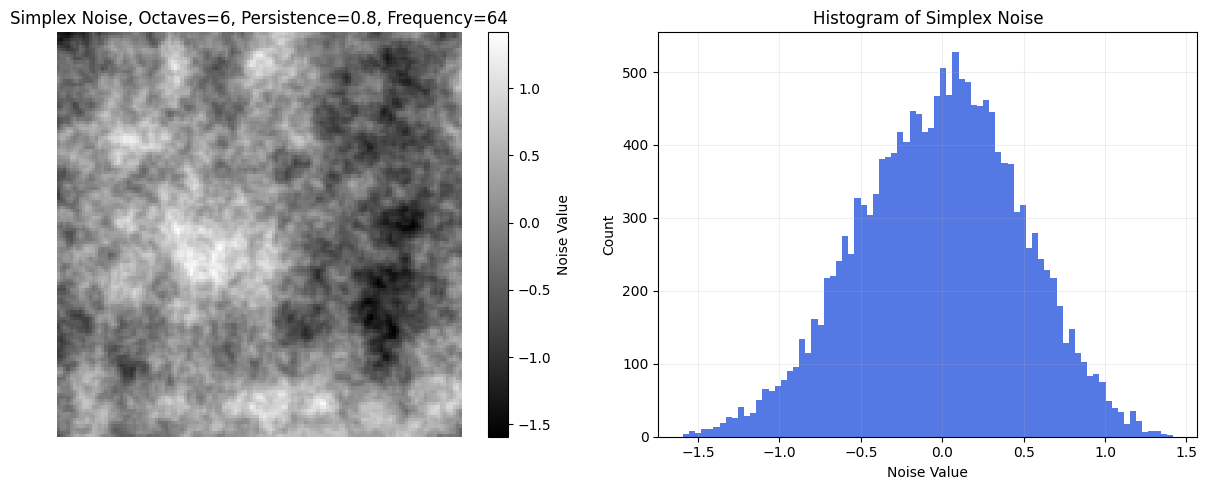

In [174]:
octaves = 6
persistence = 0.8
frequency = 64

noise = simplex_ddpm.generate_simplex_noise(simplexObj, (128,128), octaves=octaves, persistence=persistence, frequency=frequency, normalize=False)

noise_np = noise.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(noise_np, cmap='gray')#, vmin=-1.0, vmax=1.0)
plt.colorbar(im, ax=axes[0], label='Noise Value')
axes[0].set_title(f"Simplex Noise, Octaves={octaves}, Persistence={persistence}, Frequency={frequency}")
axes[0].axis('off')

axes[1].hist(noise_np.ravel(), bins=80, color='royalblue', alpha=0.9)
axes[1].set_title("Histogram of Simplex Noise")
axes[1].set_xlabel("Noise Value")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

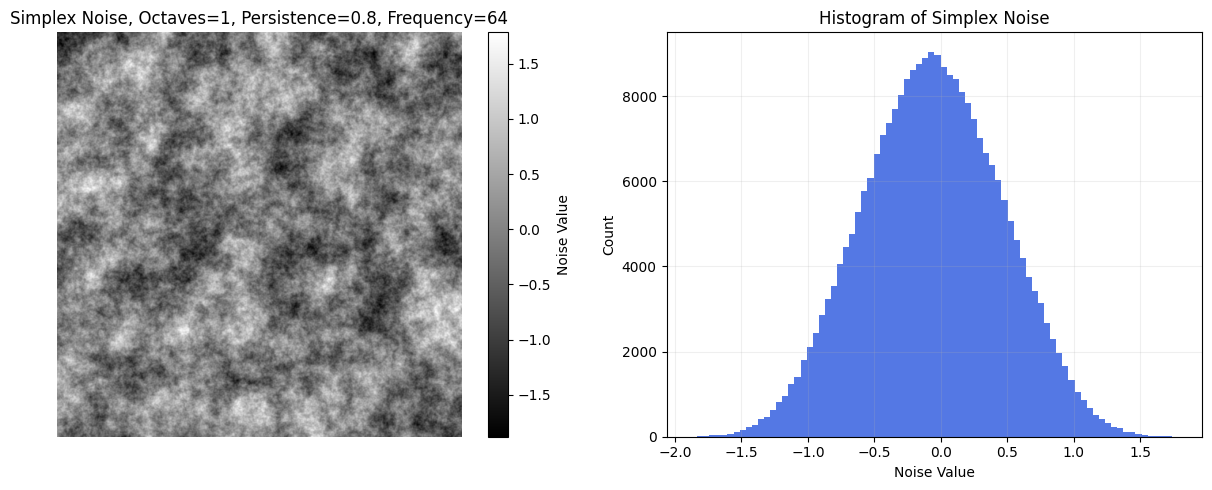

In [176]:
octaves = 1
persistence = 0.8
frequency = 64

noise = simplex_ddpm.generate_simplex_noise(simplexObj, (512,512), octaves=octaves, persistence=persistence, frequency=frequency, normalize=False)

noise_np = noise.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(noise_np, cmap='gray')#, vmin=-1.0, vmax=1.0)
plt.colorbar(im, ax=axes[0], label='Noise Value')
axes[0].set_title(f"Simplex Noise, Octaves={octaves}, Persistence={persistence}, Frequency={frequency}")
axes[0].axis('off')

axes[1].hist(noise_np.ravel(), bins=80, color='royalblue', alpha=0.9)
axes[1].set_title("Histogram of Simplex Noise")
axes[1].set_xlabel("Noise Value")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [210]:
import AnoDDPM.simplex as simplex
import torch
import numpy as np

from typing import Union

from monai.utils import StrEnum
from monai.networks.schedulers import DDPMScheduler


#@torch.compile
def my_generate_simplex_noise(simplexObj, shape, octaves=6, persistence=0.8, frequency=64, normalize=False):
    """Generate spatially correlated simplex noise."""

    simplexObj.newSeed()

    if len(shape) == 2:
        # take a slice t from the 3-dimensional noise function as we found that artefacts 
        # were introduced when sampling from the 2-dimensional noise function
        simplex = simplexObj.rand_3d_octaves(shape=(shape[0], shape[0], shape[1]), octaves=octaves, persistence=persistence, frequency=frequency)[12,...]
    elif len(shape) == 3: 
        simplex = simplexObj.rand_3d_octaves(shape=shape, octaves=octaves, persistence=persistence, frequency=frequency)
    elif len(shape) == 4 and shape[1] == 1: # 2D to make it work with shapes of type (batch_size, 1, height, width)
        simplex = simplexObj.rand_3d_octaves(shape=(shape[0], shape[2], shape[3]), octaves=octaves, persistence=persistence, frequency=frequency)
        simplex = np.expand_dims(simplex, axis=1)
    elif len(shape)==5 and shape[1] == 1 : # 3D to make it work with shapes of type (batch_size, 1, depth, height, width)
        simplex_3d_volumes = [simplexObj.rand_3d_octaves(shape=(shape[2], shape[3], shape[4]), octaves=octaves, persistence=persistence, frequency=frequency) for _ in range(shape[0])]
        simplex = np.stack(simplex_3d_volumes, axis=0)
        simplex = np.expand_dims(simplex, axis=1)
    
    if normalize:
        simplex = np.clip(simplex/3.0 + 0.5, a_min=0.0, a_max=1.0)

    return torch.tensor(simplex, dtype=torch.float32)

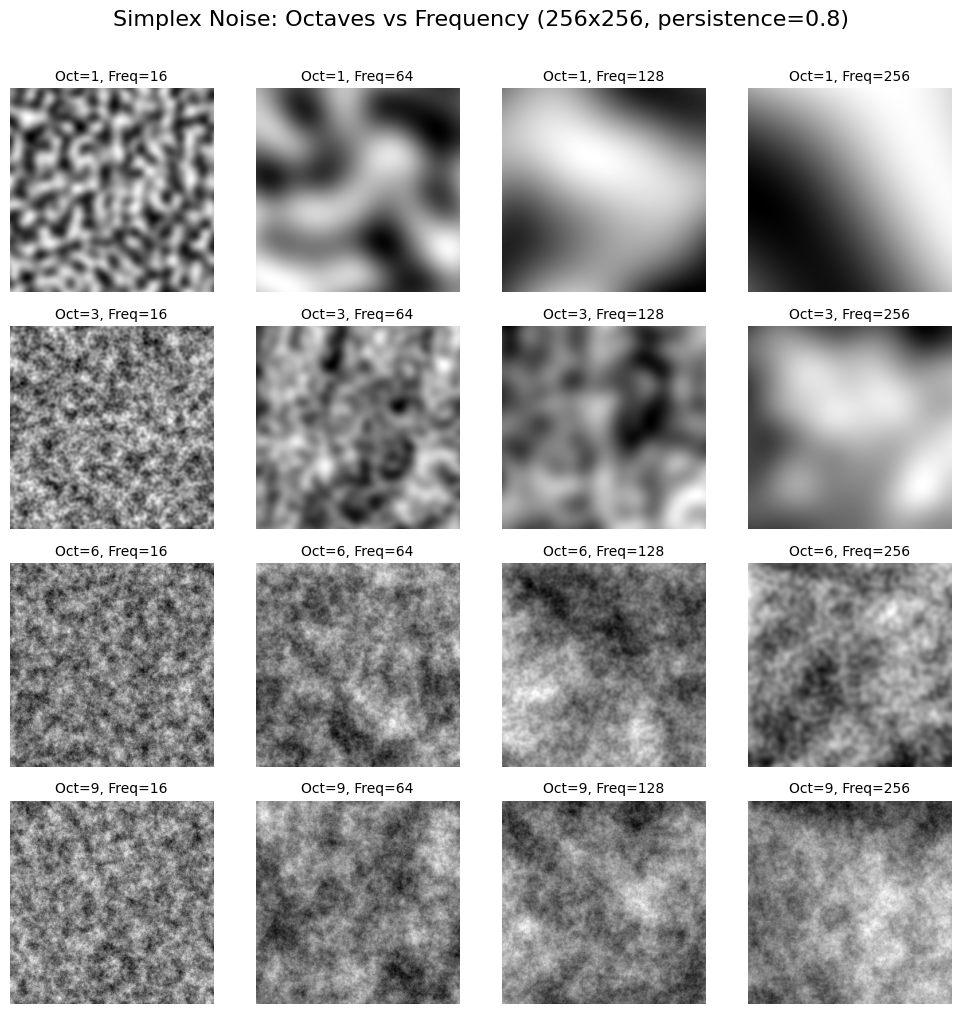

In [183]:
octaves_range = [1, 3, 6, 9]
frequency_range = [16, 64,128, 256]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for row, oct in enumerate(octaves_range):
    for col, freq in enumerate(frequency_range):
        noise_grid = generate_simplex_noise(
            simplexObj, (256, 256), octaves=oct, persistence=0.8, frequency=freq, normalize=False
        )
        axes[row, col].imshow(noise_grid.detach().cpu().numpy(), cmap='gray')
        axes[row, col].set_title(f"Oct={oct}, Freq={freq}", fontsize=10)
        axes[row, col].axis('off')

plt.suptitle("Simplex Noise: Octaves vs Frequency (256x256, persistence=0.8)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

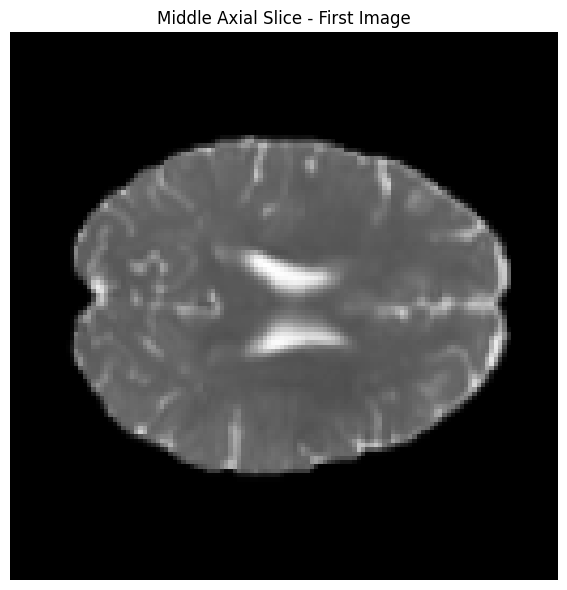

In [ ]:
# Display the middle axial slice of the first image from batch
plt.figure(figsize=(6, 6))
plt.imshow(batch[0].cpu().detach().numpy().squeeze()[...,64], cmap='gray')
plt.title("Middle Axial Slice - First Image")
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
image_sample_no_thor1, intermediates_no_thor1 = my_sample(batch[...,64].to(device), infer_scheduler, timesteps=infer_timesteps, return_intermediates=True)
image_sample_no_thor2, intermediates_no_thor2 = my_sample(batch[...,64].to(device), infer_scheduler, timesteps=infer_timesteps, return_intermediates=True)
image_sample_no_thor3, intermediates_no_thor3 = my_sample(batch[...,64].to(device), infer_scheduler, timesteps=infer_timesteps, return_intermediates=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:04<00:00, 34.57it/s]


In [ ]:
original_image = batch[0].cpu().detach().numpy().squeeze()[...,64]

In [ ]:
final_image1 = image_sample_no_thor1.cpu().detach().numpy().squeeze()
final_ano_map1 = np.abs(final_image1 - original_image)

final_image2 = image_sample_no_thor2.cpu().detach().numpy().squeeze()
final_ano_map2 = np.abs(final_image2 - original_image)

final_image3 = image_sample_no_thor3.cpu().detach().numpy().squeeze()
final_ano_map3 = np.abs(final_image3 - original_image)

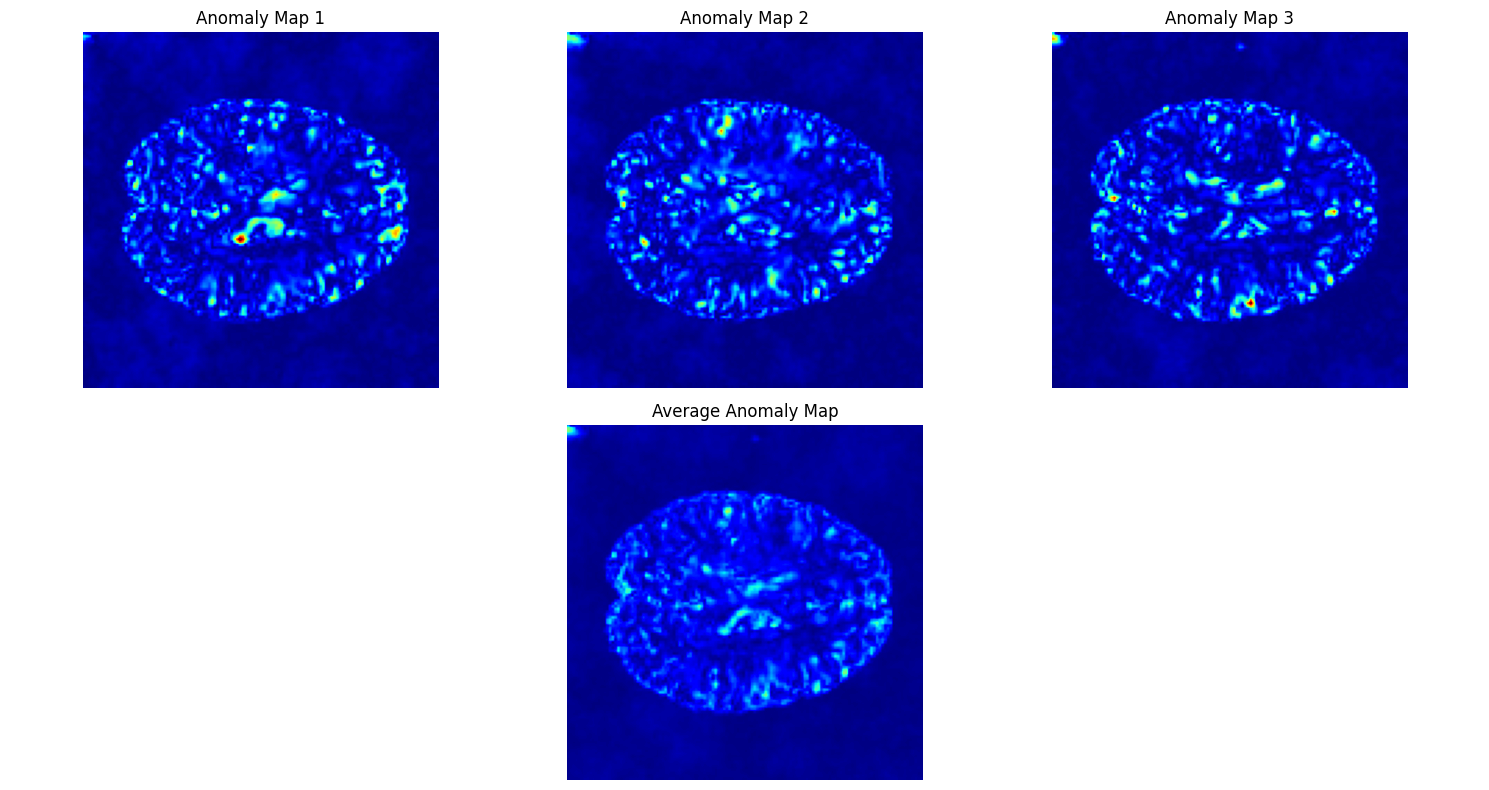

In [ ]:
avg_ano_map = (final_ano_map1 + final_ano_map2 + final_ano_map3) / 3.0

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# First row: individual anomaly maps
axes[0, 0].imshow(final_ano_map1, cmap='jet', vmin=0, vmax=0.2)
axes[0, 0].set_title("Anomaly Map 1")
axes[0, 0].axis('off')

axes[0, 1].imshow(final_ano_map2, cmap='jet', vmin=0, vmax=0.2)
axes[0, 1].set_title("Anomaly Map 2")
axes[0, 1].axis('off')

axes[0, 2].imshow(final_ano_map3, cmap='jet', vmin=0, vmax=0.2)
axes[0, 2].set_title("Anomaly Map 3")
axes[0, 2].axis('off')

# Second row: average map (centered)
axes[1, 1].imshow(avg_ano_map, cmap='jet', vmin=0, vmax=0.2)
axes[1, 1].set_title("Average Anomaly Map")
axes[1, 1].axis('off')

# Hide unused axes on second row
axes[1, 0].axis('off')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
nb_inferences = 30
final_images = []
final_ano_maps = []

for i in tqdm(range(nb_inferences)):
    image_sample_no_thor, _ = my_sample(batch[...,64].to(device), infer_scheduler, timesteps=infer_timesteps, return_intermediates=True)
    final_image = image_sample_no_thor.cpu().detach().numpy().squeeze()
    final_ano_map = np.abs(final_image - original_image)
    final_images.append(final_image)
    final_ano_maps.append(final_ano_map)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [02:10<00:00,  4.34s/it]


In [ ]:
average_ano_map = np.mean(final_ano_maps, axis=0)

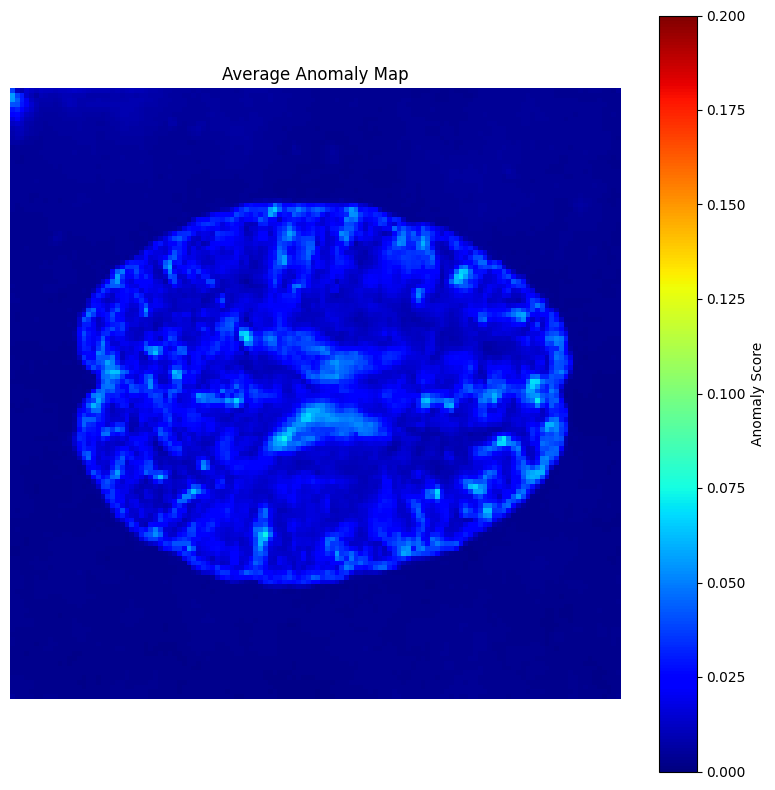

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(average_ano_map, cmap='jet', vmin=0, vmax=0.2)
plt.colorbar(label='Anomaly Score')
plt.title("Average Anomaly Map")
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
stroke_patient = "sub-303"
stroke_image_path = ROOT_DIR+f"datasets/final_soop_dataset_small/adc_registered/{stroke_patient}.nii.gz"

In [ ]:
import nibabel as nib

In [ ]:
#test_reconstruction_datalist = sorted(test_reconstruction_images_path)
test_stroke_datalist = [stroke_image_path]

#test_unhealthy_datalist = test_unhealthy_images_path

#batch_size = args.dataset["batch_size"]
batch_size = 1
num_workers = 1
#num_workers = args.dataset["num_workers"]


# transforms
test_stroke_transforms = define_instance(args, "val_transforms")
test_stroke_ds = CacheDataset(data=test_stroke_datalist[:batch_size], transform=test_stroke_transforms)


test_stroke_loader = DataLoader(
    test_stroke_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)

Loading dataset: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.60it/s]


In [ ]:
stroke_batch = next(iter(test_stroke_loader))[...,64].to(device)

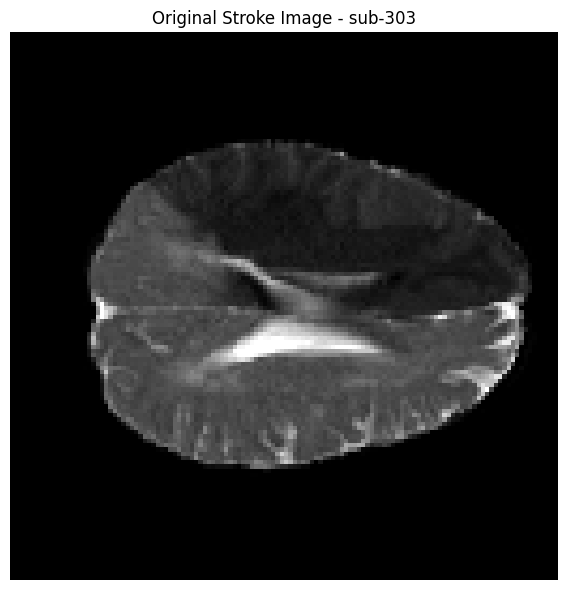

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(stroke_batch.cpu().detach().numpy().squeeze(), cmap='gray')
plt.title(f"Original Stroke Image - {stroke_patient}")
plt.axis('off')
plt.tight_layout()
plt.show()

In [213]:
stroke_inference_custom_noise, intermediates_custom_noise = my_sample(stroke_batch, infer_scheduler, timesteps=90, octaves=1, frequency=256, return_intermediates=True)

  0%|                                                                                                                                                                                         | 0/90 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 90/90 [00:02<00:00, 34.75it/s]


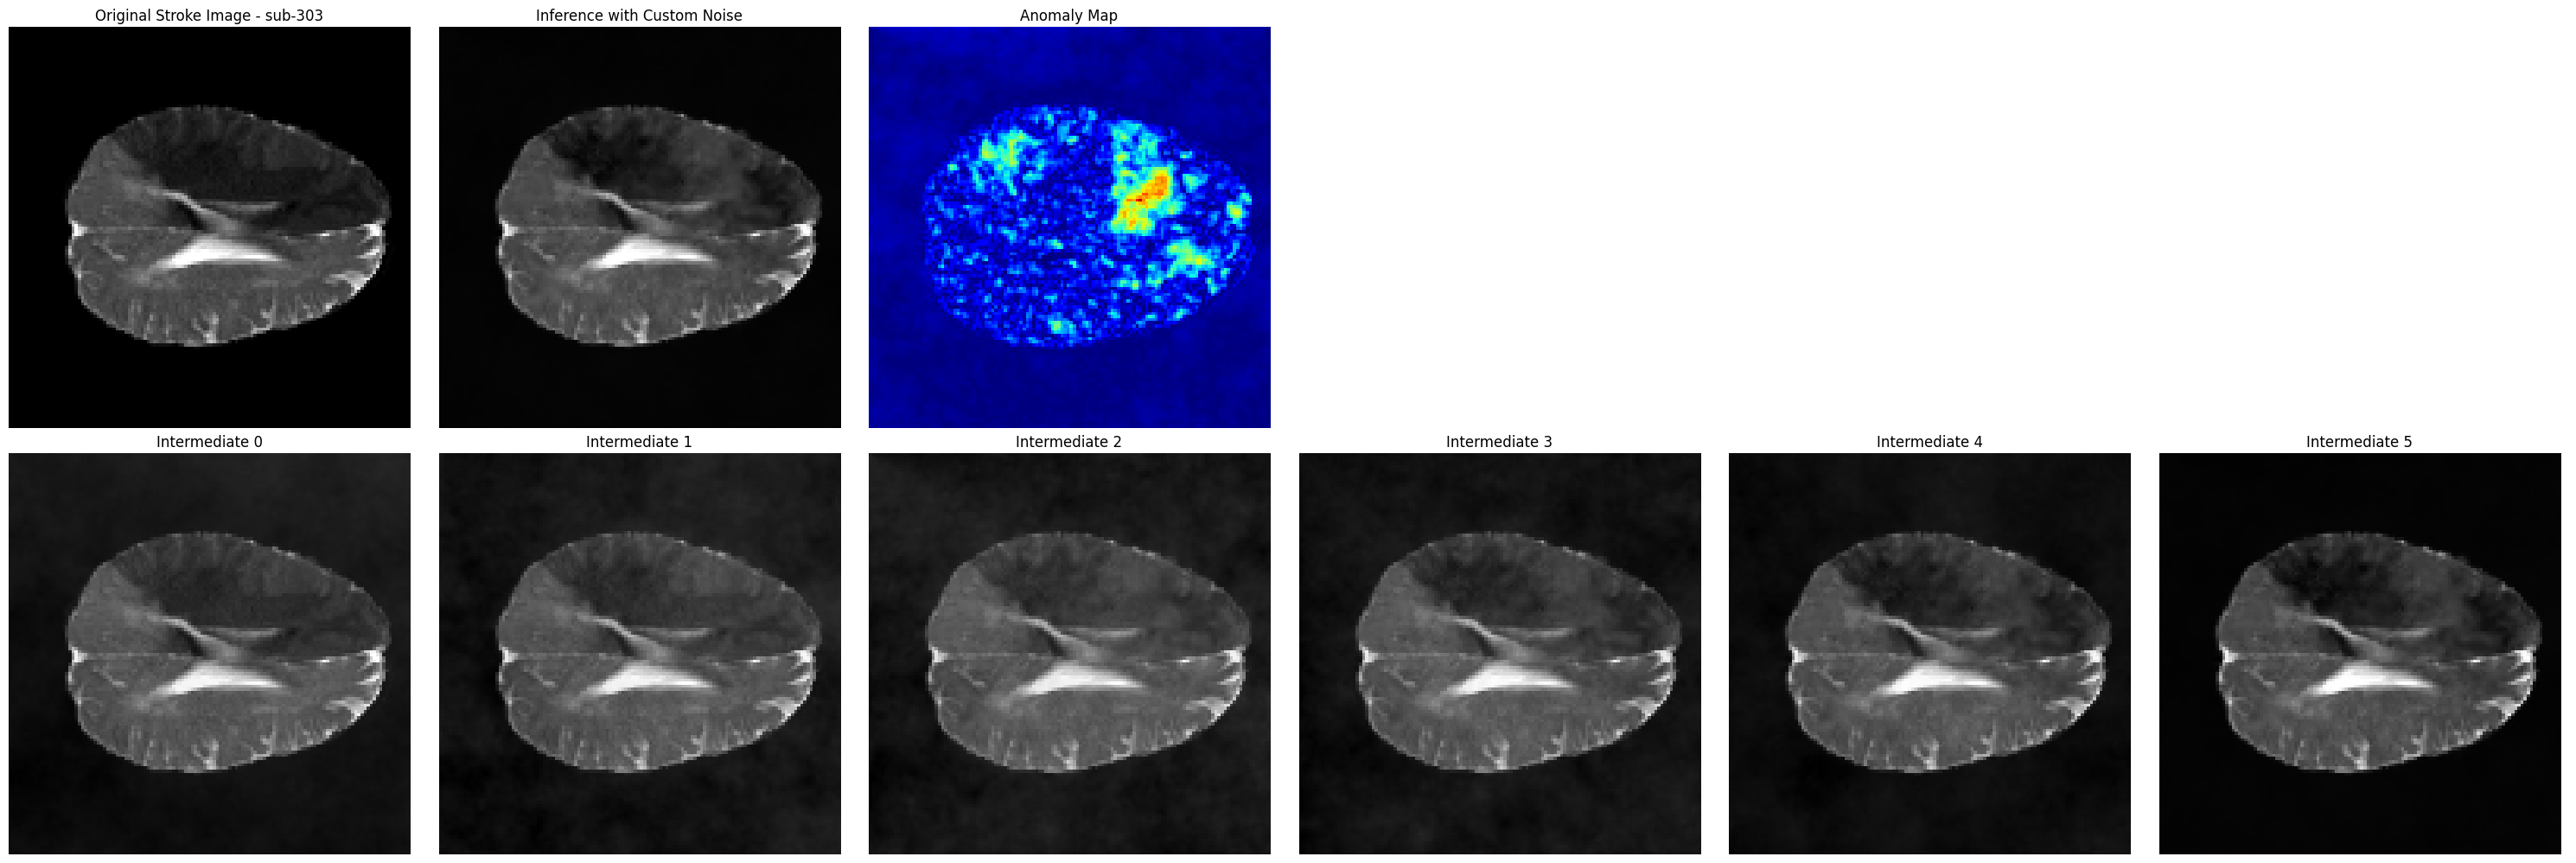

In [214]:
stroke_original = stroke_batch[0].cpu().detach().numpy().squeeze()
stroke_inferred = stroke_inference_custom_noise[0].cpu().detach().numpy().squeeze()
ano_map = np.abs(stroke_inferred - stroke_original)

n_intermediates = len(intermediates_custom_noise)

fig, axes = plt.subplots(2, max(n_intermediates, 2), figsize=(5 * max(n_intermediates, 2), 10))

# Top row: original and inference result
axes[0, 0].imshow(stroke_original, cmap='gray')
axes[0, 0].set_title(f"Original Stroke Image - {stroke_patient}")
axes[0, 0].axis('off')

axes[0, 1].imshow(stroke_inferred, cmap='gray')
axes[0, 1].set_title("Inference with Custom Noise")
axes[0, 1].axis('off')

axes[0, 2].imshow(ano_map, cmap='jet', vmin=0, vmax=0.2)
axes[0, 2].set_title("Anomaly Map")
axes[0, 2].axis('off')

for i in range(2, max(n_intermediates, 2)):
    axes[0, i].axis('off')

# Bottom row: intermediates
for i in range(n_intermediates):
    img = intermediates_custom_noise[i][0].cpu().detach().numpy().squeeze()
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title(f"Intermediate {i}")
    axes[1, i].axis('off')

for i in range(n_intermediates, max(n_intermediates, 2)):
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
nb_inferences = 30
final_images = []
final_ano_maps = []

In [139]:
stroke_batch.shape

torch.Size([1, 1, 128, 128])

In [141]:
batch_inference_stroke = stroke_batch.repeat(nb_inferences, 1, 1, 1)

In [142]:
batch_inference_stroke.shape

torch.Size([30, 1, 128, 128])

In [143]:
stroke_infered_batch, intermediates_stroke = my_sample(batch_inference_stroke, infer_scheduler, timesteps=90, return_intermediates=True)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 90/90 [00:34<00:00,  2.63it/s]


In [152]:
stroke_infered_batch.shape

torch.Size([30, 1, 128, 128])

In [144]:
stroke_final_ano_maps = np.abs(stroke_infered_batch.cpu().detach().numpy() - batch_inference_stroke.cpu().detach().numpy())

In [146]:
average_ano_map = np.mean(stroke_final_ano_maps, axis=0)
max_ano_map = np.max(stroke_final_ano_maps, axis=0)
harmonic_mean_ano_map = stats.hmean(np.array(stroke_final_ano_maps) + 1e-8, axis=0)

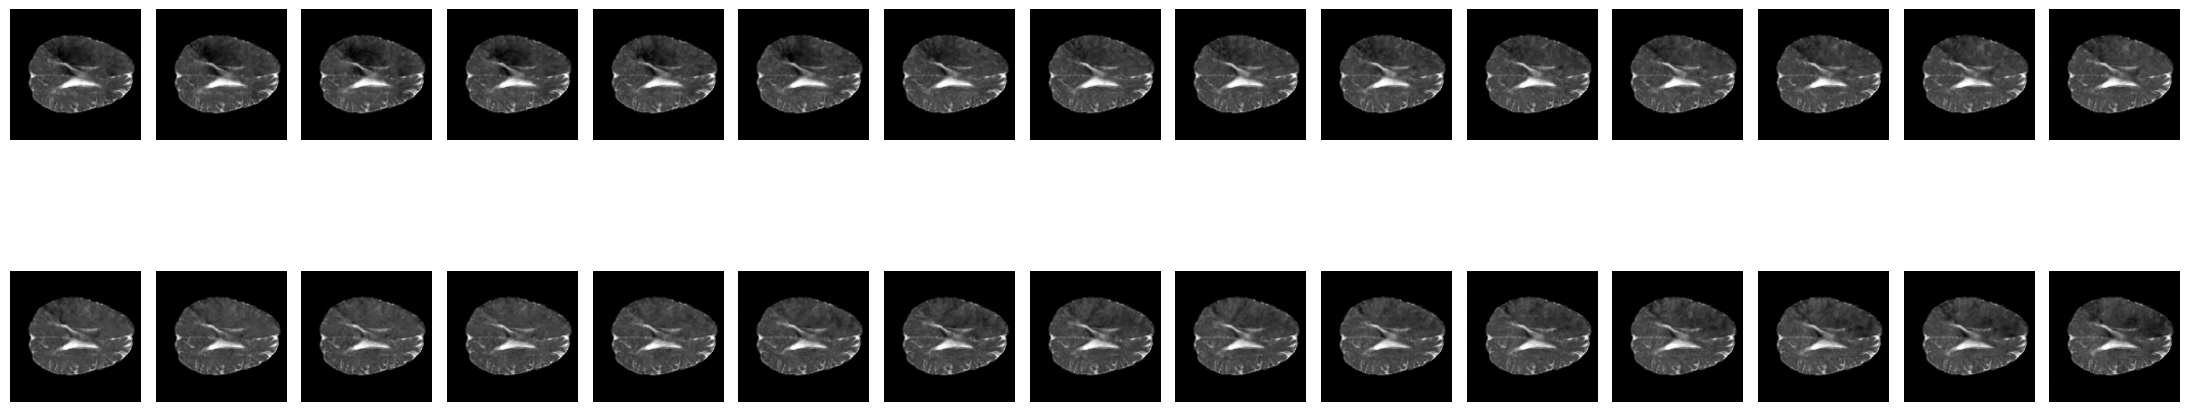

In [151]:
fig, axes = plt.subplots(2, 15, figsize=(22, 8))
plt.tight_layout()
for i in range(30):
    row = i // 15
    col = i % 15
    axes[row, col].imshow(stroke_infered_batch[i].squeeze().cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)
    #axes[i].set_title(f"Anomaly Map {i+1}")
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

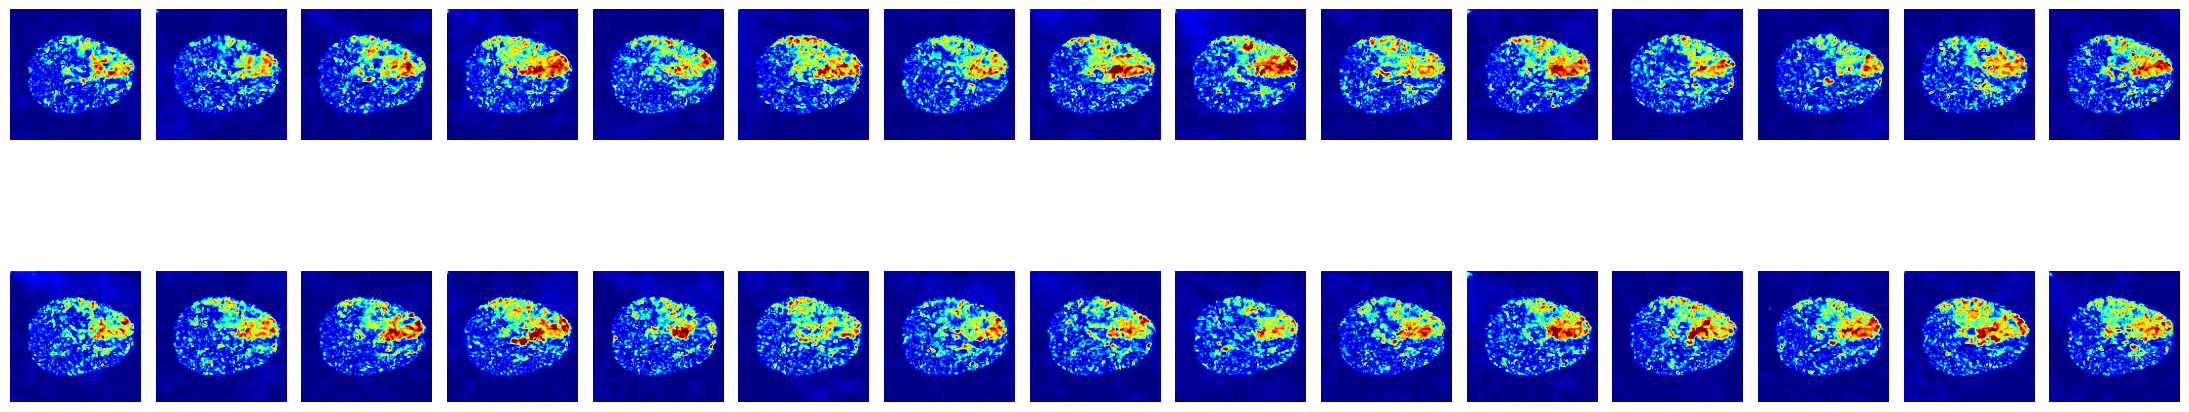

In [162]:
fig, axes = plt.subplots(2, 15, figsize=(22, 8))
plt.tight_layout()
for i in range(30):
    row = i // 15
    col = i % 15
    axes[row, col].imshow(stroke_final_ano_maps[i].squeeze(), cmap='jet', vmin=0, vmax=0.2)
    #axes[i].set_title(f"Anomaly Map {i+1}")
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

(-0.5, 127.5, 127.5, -0.5)

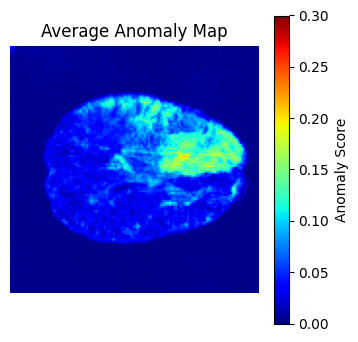

In [156]:
plt.figure(figsize=(4, 4))
plt.imshow(average_ano_map.squeeze(), cmap='jet', vmin=0, vmax=0.3)
plt.colorbar(label='Anomaly Score')
plt.title("Average Anomaly Map")
plt.axis('off')

(-0.5, 127.5, 127.5, -0.5)

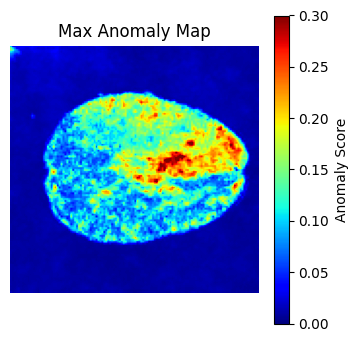

In [157]:
plt.figure(figsize=(4, 4))
plt.imshow(max_ano_map.squeeze(), cmap='jet', vmin=0, vmax=0.3)
plt.colorbar(label='Anomaly Score')
plt.title("Max Anomaly Map")
plt.axis('off')

(-0.5, 127.5, 127.5, -0.5)

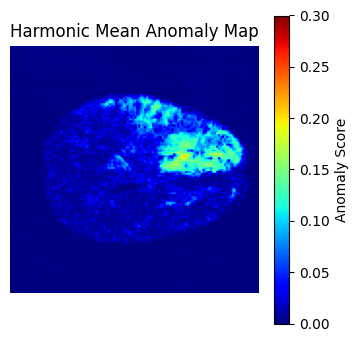

In [158]:
plt.figure(figsize=(4, 4))
plt.imshow(harmonic_mean_ano_map.squeeze(), cmap='jet', vmin=0, vmax=0.3)
plt.colorbar(label='Anomaly Score')
plt.title("Harmonic Mean Anomaly Map")
plt.axis('off')

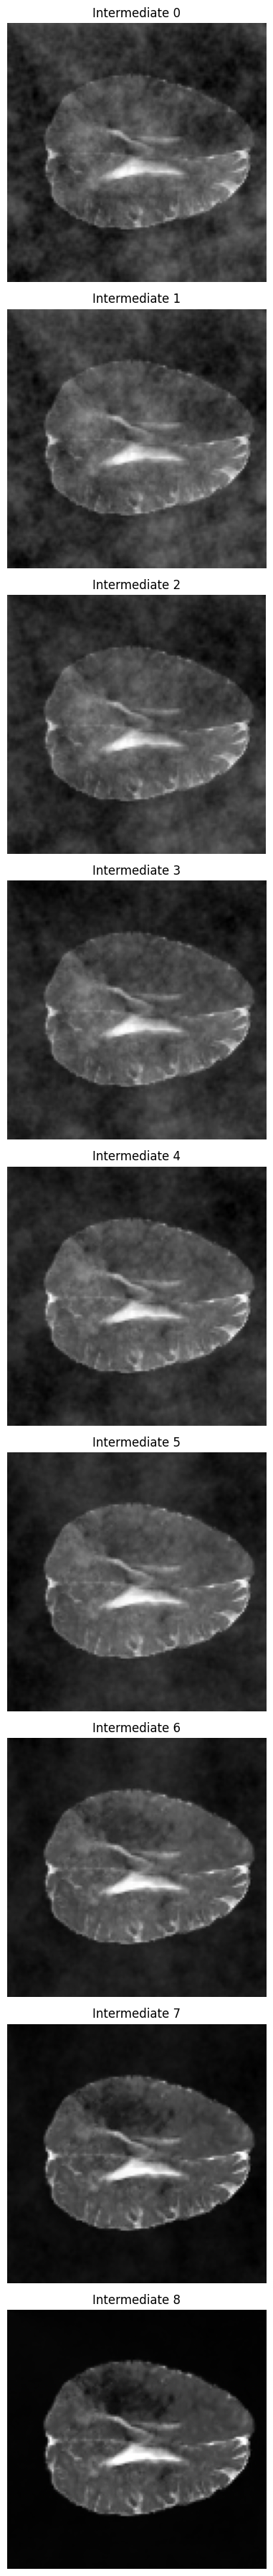

In [89]:
fig, axes = plt.subplots(len(intermediates_stroke), 1, figsize=(6, 4*len(intermediates_stroke)))
if len(intermediates_stroke) == 1:
    axes = [axes]

for idx, intermediate in enumerate(intermediates_stroke):
    infered_image = intermediate[0].cpu().detach().numpy().squeeze()
    original_image_slice = stroke_batch[0].cpu().detach().numpy().squeeze()
    
    axes[idx].imshow(infered_image, cmap='gray')
    axes[idx].set_title(f"Intermediate {idx}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

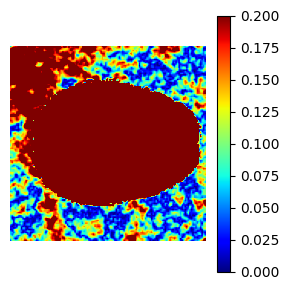

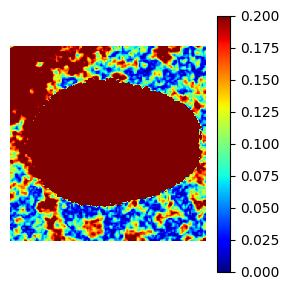

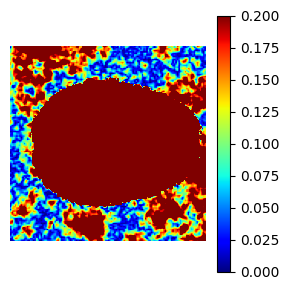

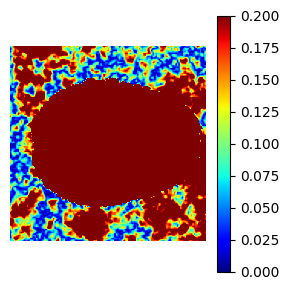

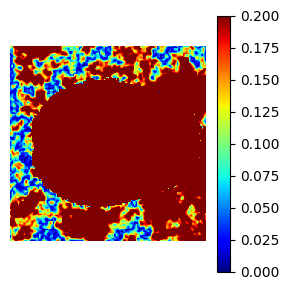

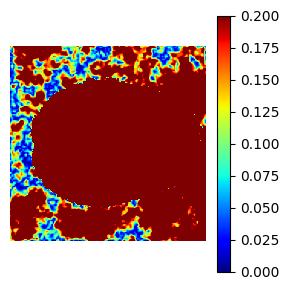

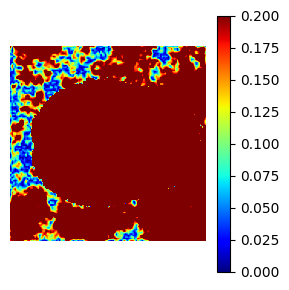

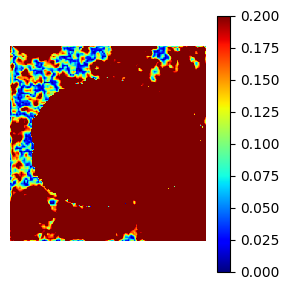

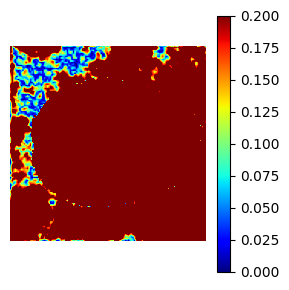

In [76]:
for int in intermediates_stroke:
    infered_image = int[0].cpu().detach().numpy().squeeze()
    origial_image = stroke_img[...,64]

    #print(infered_image.shape)
    #print(origial_image.shape)

    # display the middle axial slice of the first image from batch
    plt.figure(figsize=(3, 3))
    plt.imshow(np.abs(infered_image - origial_image), cmap='jet', vmin=0, vmax=0.2)
    # add colorbar
    plt.colorbar()
    #plt.title("Middle Axial Slice - First Image - Intermediate")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [11]:
ano_dataset = anomaly_datasets.SOOP_Fast(args)

Loading dataset:  24%|██████████████████████████████████████▏                                                                                                                       | 28/116 [00:33<01:44,  1.19s/it]


KeyboardInterrupt: 

In [19]:
mask_ground_truth_batch = next(iter(ano_dataset.test_masks_large_loader_metrics))
mask_ground_truth_batch = mask_ground_truth_batch.to(device)

batch = next(iter(ano_dataset.test_anomaly_large_loader_metrics))
batch = batch.to(device)


In [20]:
mask_ground_truth_batch = mask_ground_truth_batch[...,64] # select middle axial slice

In [21]:
batch = batch[...,64] # select middle axial slice

In [22]:
infer_timesteps = 100

#timesteps_harmonization = np.linspace(50, infer_timesteps, num=2, dtype=int).tolist()
timesteps_harmonization = [80, 40] # timesteps at which we apply the harmonization
print(timesteps_harmonization)

[80, 40]


In [69]:
image, intermediates_mixed_images_visualize, intermediates_pseudo_anomaly_masks, intermediates_pseudo_anomaly_masks_processed = sample_thor(batch, infer_scheduler, timesteps=infer_timesteps, timesteps_harmonization=timesteps_harmonization, return_intermediates=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [03:41<00:00,  2.21s/it]


In [72]:
harmonic_mean = stats.hmean(np.stack([p.cpu() for p in intermediates_pseudo_anomaly_masks_processed]), axis=0)

In [24]:
image_sample_no_thor, intermediates_no_thor = my_sample(batch, infer_scheduler, timesteps=infer_timesteps, return_intermediates=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:47<00:00,  2.09it/s]


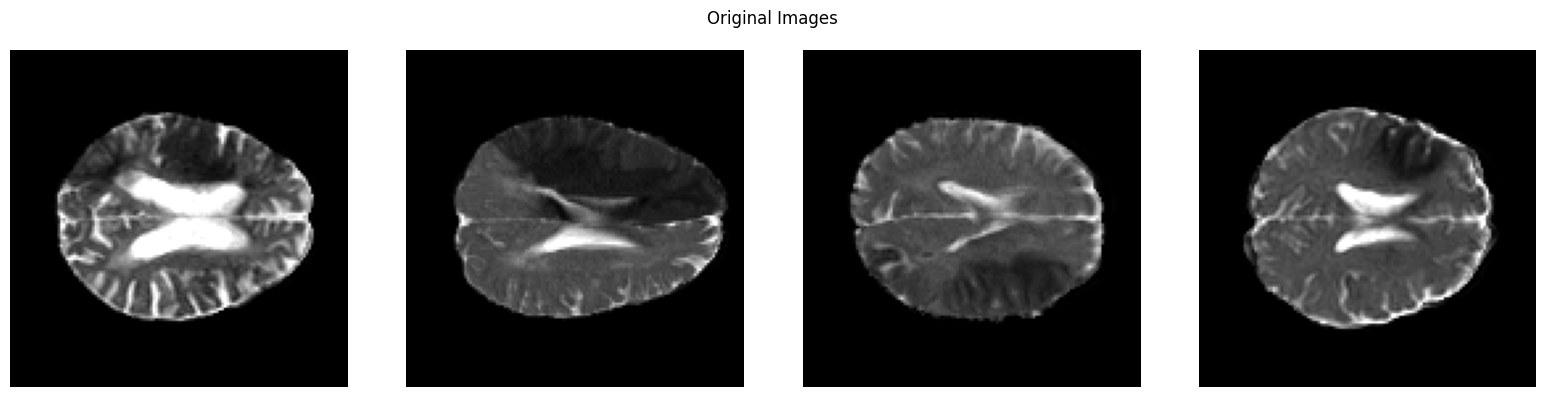

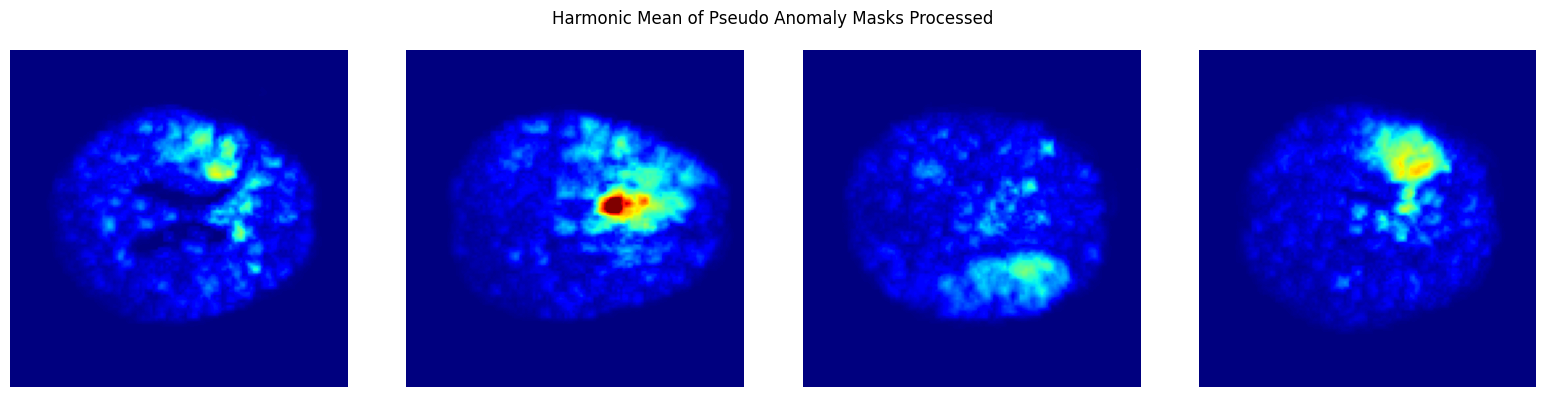

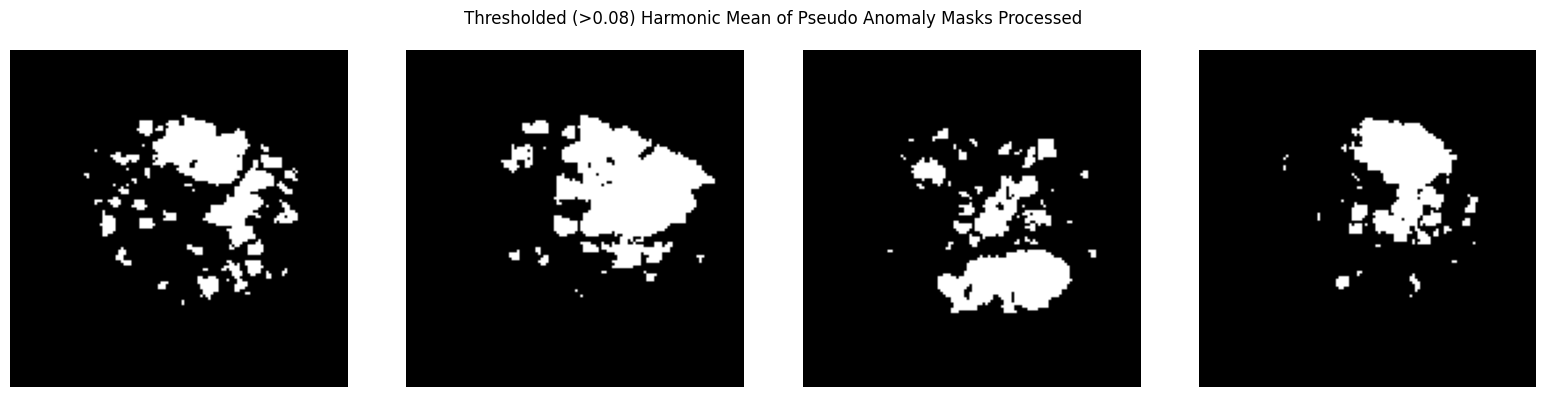

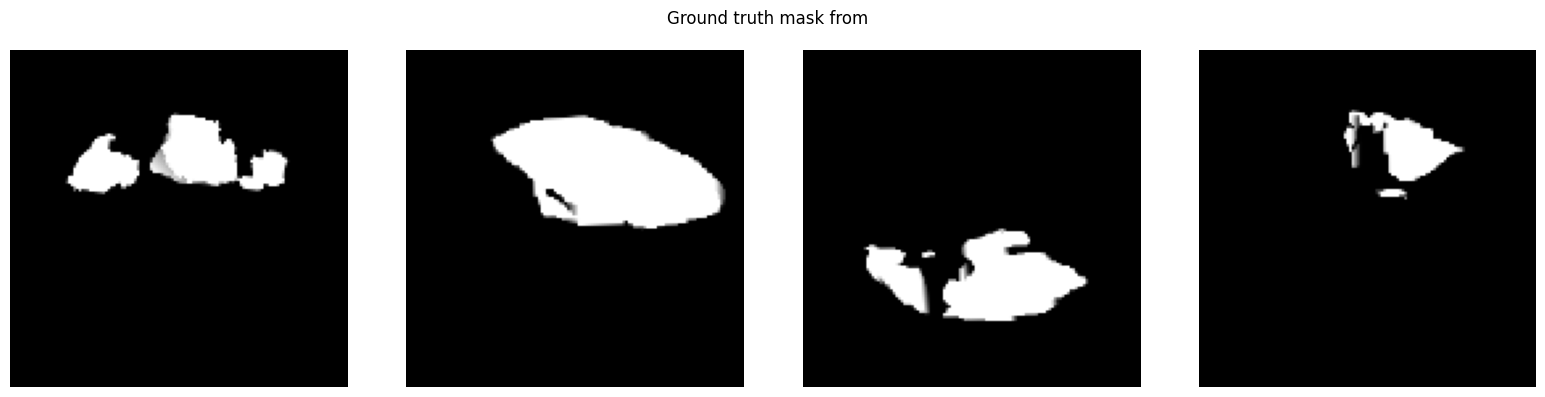

In [75]:
image_number = 0
threshold = 0.08

# ----------------------------------------------------------------------------
# Plot the original image (batch index 1)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axes[i].imshow(batch[image_number + i].cpu().detach().numpy().squeeze(), cmap='gray')
    #axes[i].set_title(f"Original Image {image_number + i}")
    axes[i].axis('off')
plt.suptitle("Original Images")
plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------------
""" # Plot the first image (batch index 1) from each visualize image side by side
visu = intermediates_mixed_images_visualize
n = len(visu)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
plt.suptitle("Visualization infered images at Different Harmonization Timesteps")
if n == 1:
    axes = [axes]

for i, v in enumerate(visu):
    img = v[image_number].detach().float().cpu().numpy().squeeze()  # (H, W)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"timestep {timesteps_harmonization[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show() """


# ----------------------------------------------------------------------------
# Plot the first image (batch index 1) from each pseudo anomaly mask side by side
""" masks = intermediates_pseudo_anomaly_masks
n = len(masks)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
plt.suptitle("Pseudo Anomaly Masks at Different Harmonization Timesteps")
if n == 1:
    axes = [axes]

for i, m in enumerate(masks):
    img = m[image_number].detach().float().cpu().numpy().squeeze()  # (H, W)
    axes[i].imshow(img, cmap='hot')
    axes[i].set_title(f"timestep {timesteps_harmonization[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show() """


# ----------------------------------------------------------------------------
# Plot the first image (batch index 1) from each pseudo anomaly mask processed side by side
""" masks = intermediates_pseudo_anomaly_masks_processed
n = len(masks)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
plt.suptitle("Pseudo Anomaly Masks Processed at Different Harmonization Timesteps")
if n == 1:
    axes = [axes]

for i, m in enumerate(masks):
    img = m[image_number].detach().float().cpu().numpy().squeeze()  # (H, W)
    axes[i].imshow(img, cmap='hot')
    axes[i].set_title(f"timestep {timesteps_harmonization[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show() """


# ----------------------------------------------------------------------------
# Plot the harmonic mean of intermediates_pseudo_anomaly_masks_processed (batch index 1)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axes[i].imshow(harmonic_mean[image_number + i].squeeze(), cmap='jet', vmin=0.0, vmax=0.5)
    #axes[i].set_title(f"Original Image {image_number + i}")
    axes[i].axis('off')
plt.suptitle("Harmonic Mean of Pseudo Anomaly Masks Processed")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# Plot the thresholded harmonic mean of intermediates_pseudo_anomaly_masks_processed (batch index 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axes[i].imshow((harmonic_mean[image_number+i].squeeze() > threshold).astype(float), cmap='gray')
    #axes[i].set_title(f"Original Image {image_number + i}")
    axes[i].axis('off')
plt.suptitle(f"Thresholded (>{threshold}) Harmonic Mean of Pseudo Anomaly Masks Processed")
plt.tight_layout()
plt.show()



# ----------------------------------------------------------------------------
# Plot the anomaly difference for regular sample (no thor) (batch index 1)
""" plt.figure(figsize=(4,4))
plt.imshow(np.abs(image_sample_no_thor[image_number].cpu().detach().numpy().squeeze()-batch[image_number].cpu().detach().numpy().squeeze()), cmap='hot', vmin=0.0, vmax=0.5)
plt.title("anomaly difference for regular sample (no thor) ")
plt.axis('off')
plt.show() """




# ----------------------------------------------------------------------------
# Plot the ground truth mask (batch index 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axes[i].imshow(mask_ground_truth_batch[image_number+i].cpu().detach().numpy().squeeze(), cmap='gray')
    #axes[i].set_title(f"Original Image {image_number + i}")
    axes[i].axis('off')
plt.suptitle("Ground truth mask from  ")
plt.tight_layout()
plt.show()



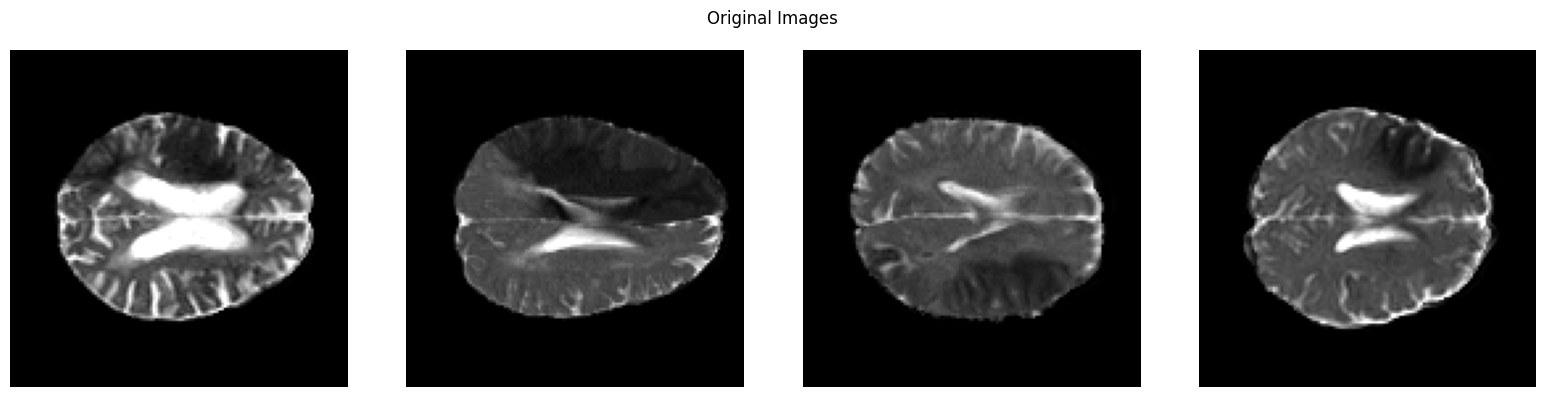

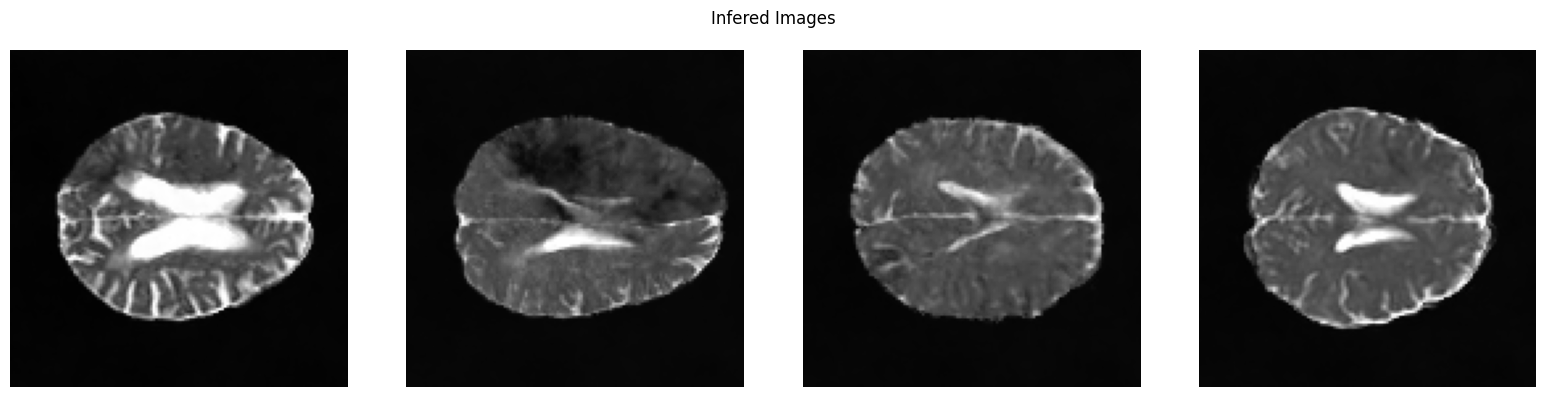

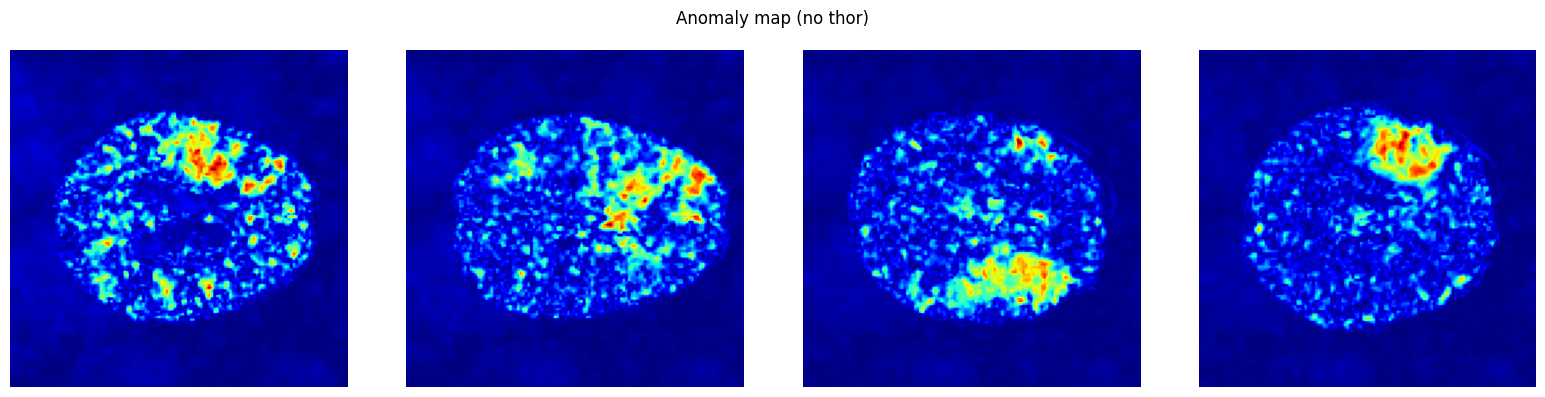

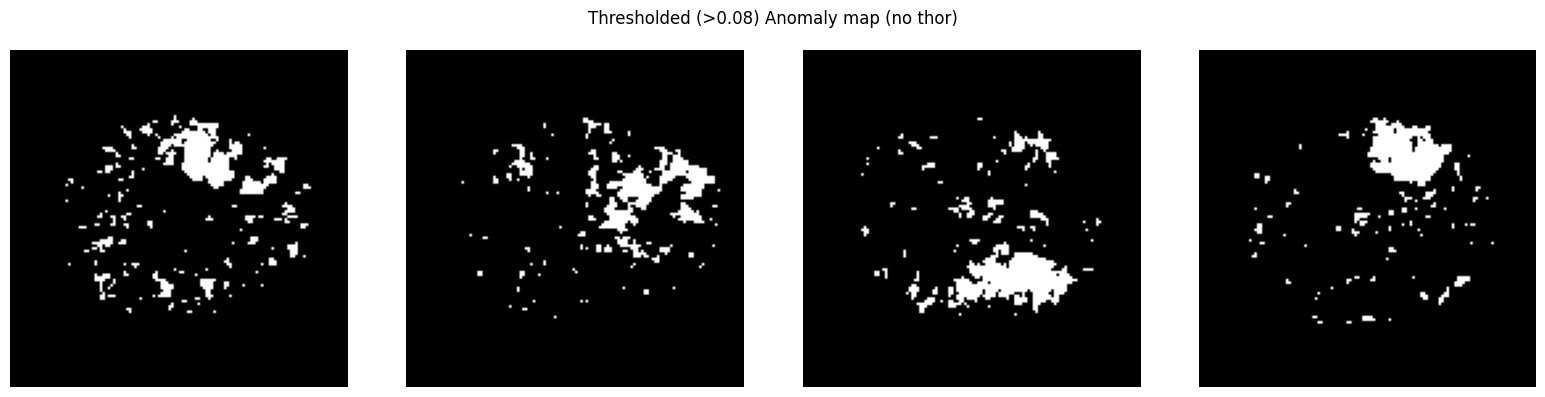

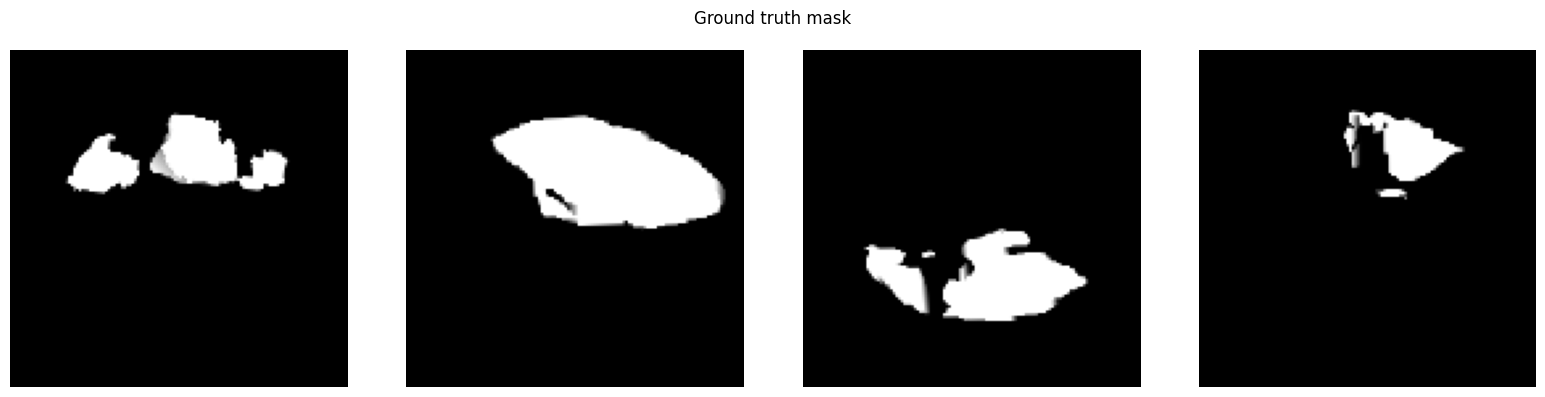

In [25]:
image_number = 0
threshold = 0.08


original_image = batch.cpu().detach().numpy().squeeze()

infered_image = scale_intensity_from_histogram_peak(image_sample_no_thor.cpu().detach().numpy().squeeze(), target_value=2.0/7.0)

# ----------------------------------------------------------------------------
# Plot the original image (batch index 1)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axes[i].imshow(original_image[image_number + i], cmap='gray')
    #axes[i].set_title(f"Original Image {image_number + i}")
    axes[i].axis('off')
plt.suptitle("Original Images")
plt.tight_layout()
plt.show()

# Plot the infered image (batch index 1)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axes[i].imshow(infered_image[image_number + i], cmap='gray')
    #axes[i].set_title(f"Original Image {image_number + i}")
    axes[i].axis('off')
plt.suptitle("Infered Images")
plt.tight_layout()
plt.show()



# ----------------------------------------------------------------------------
# Plot the harmonic mean of intermediates_pseudo_anomaly_masks_processed (batch index 1)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axes[i].imshow(np.abs(original_image - infered_image)[image_number + i], cmap='jet')
    #axes[i].set_title(f"Original Image {image_number + i}")
    axes[i].axis('off')
plt.suptitle("Anomaly map (no thor)")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# Plot the thresholded harmonic mean of intermediates_pseudo_anomaly_masks_processed (batch index 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axes[i].imshow(np.abs(original_image - infered_image)[image_number + i]>threshold, cmap='gray')
    #axes[i].set_title(f"Original Image {image_number + i}")
    axes[i].axis('off')
plt.suptitle(f"Thresholded (>{threshold}) Anomaly map (no thor)")
plt.tight_layout()
plt.show()



# ----------------------------------------------------------------------------
# Plot the ground truth mask (batch index 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axes[i].imshow(mask_ground_truth_batch[image_number+i].cpu().detach().numpy().squeeze(), cmap='gray')
    #axes[i].set_title(f"Original Image {image_number + i}")
    axes[i].axis('off')
plt.suptitle("Ground truth mask")
plt.tight_layout()
plt.show()



#### **Le pb c'est kobra je crois, aller sur gricad avec un autre environment genre ddpm_env**

#### **TODO: add scaleintensity by histogram après inférence de my_sample (no_thor) !!!**

#### **TODO: add scaleintensity by histogram peak dans sample_thor !!!**